In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
# [LLM] -- [Human] -- [Tool Executor]

# interrupt -> 사람이 관여한다. 
# interrupt 이후 Command -> 명령 -> 멈췄던 워크플로우를 다음 단계로 진행

In [3]:
# LLM 선언 - AzureOpenAI 로 활용해도 됨

from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o-mini") 
small_llm = ChatOpenAI(model="gpt-4o-mini")

In [4]:
from langchain_core.tools import tool


@tool
def add(a: int, b:int) -> int:
    """
        숫자 a 와 b를 더합니다    
    """
    return a + b


@tool
def multiply(a: int, b: int) -> int:
    """
        숫자 a 와 b를 곱합니다    
    """
    return a * b


In [5]:
from langchain_community.tools import DuckDuckGoSearchRun


search_tool = DuckDuckGoSearchRun()

In [6]:
# Gmail 도구를 추가
from langchain_google_community.gmail.utils import (
    build_resource_service,
    get_gmail_credentials,
)
from langchain_google_community import GmailToolkit

# 이 방식을 추천 => 변수를 넘기면서 credential, token json 파일을 관리할 수 있다
credentials = get_gmail_credentials(
    token_file="./google/gmail_token.json",   # credentials를 기반으로 메일 권한을 가지고 토큰을 생성해서 파일에 저장
    scopes=["https://mail.google.com/"],
    client_sercret_file="./google/gmail_credentials.json",   #client_sercret_file 오타가 있는 파라미터로...
)
api_resource = build_resource_service(credentials=credentials)
gmail_toolkit = GmailToolkit(api_resource=api_resource)

# 한번 인증을 받으면, 다시 실행해도 넘어간다. 
# gmail_toolkit에서 도구를 받아올 수 있는 상태. 
gmail_tool_list = gmail_toolkit.get_tools()
# toolkit = GmailToolkit()   # 이걸 활용하고자 한다면 -> 파일 이름 명시 불가. credential.json이라고만 해줘야 함 (위 코드 참고)

C:\Users\KE126\AppData\Local\Temp\ipykernel_2660\1902096436.py:9: DeprecationWarning: get_gmail_credentials is deprecated and will be removed in a future version.Use get_google_credentials instead.
  credentials = get_gmail_credentials(
C:\Users\KE126\AppData\Local\Temp\ipykernel_2660\1902096436.py:14: DeprecationWarning: build_resource_service is deprecated and will be removed in a future version.Use build_gmail_service instead.
  api_resource = build_resource_service(credentials=credentials)


In [7]:
gmail_tool_list
# %pip freeze > requirements.txt

[GmailCreateDraft(api_resource=<googleapiclient.discovery.Resource object at 0x000001AF83951BE0>),
 GmailSendMessage(api_resource=<googleapiclient.discovery.Resource object at 0x000001AF83951BE0>),
 GmailSearch(api_resource=<googleapiclient.discovery.Resource object at 0x000001AF83951BE0>),
 GmailGetMessage(api_resource=<googleapiclient.discovery.Resource object at 0x000001AF83951BE0>),
 GmailGetThread(api_resource=<googleapiclient.discovery.Resource object at 0x000001AF83951BE0>)]

In [8]:
# 아카이브 논문 툴
# from langchain.agents import load_tools  # ImportError: cannot import name 'load_tools' from 'langchain.agents'  에러
from langchain_community.agent_toolkits.load_tools import load_tools
from langchain_openai import ChatOpenAI

# llm = ChatOpenAI(temperature=0.0)
loaded_tool_list = load_tools(
    ["arxiv"],
)


#### create_retriever_tool

In [9]:
from langchain_openai import OpenAIEmbeddings
from langchain_chroma import Chroma
from langchain_core.tools.retriever import create_retriever_tool  


embedding_function = OpenAIEmbeddings(model="text-embedding-3-large")

vector_store = Chroma(
    embedding_function=embedding_function,
    collection_name='real_estate_tax',
    persist_directory='./real_estate_tax_collection'  # 로컬에 남아있음
)

retriever = vector_store.as_retriever(search_kwargs={"k": 3})  # 검색할 때, 가장 유사한 3개의 문서를 가져오도록 설정

retriever_tool = create_retriever_tool(
    retriever=retriever,
    name='real_estate_tax_retriever',
    description='Contains information about real estate tax'
)

#### langgraph에서 ToolNode

In [10]:
from langgraph.prebuilt import ToolNode

# tool_list = [add, multiply, search_tool, gmail_tool_list]
tool_list = [add, multiply, search_tool, retriever_tool] + gmail_tool_list  + loaded_tool_list

llm_with_tools = small_llm.bind_tools(tool_list)  # LLM 바인딩 
tool_node = ToolNode(tool_list)   # 랭그래프 바인딩 

In [11]:
# state 선언 : messages의 경우, langgraph가 내장으로 제공하는 state가 있다
from langgraph.graph import MessagesState, StateGraph

class AgentState(MessagesState):
    summary: str

# graph_builder = StateGraph(MessagesState)
graph_builder = StateGraph(AgentState)



In [12]:
# 1. 에이전트 노드를 생성 <- LLM을 호출하는, llm_with_tools는 messages를 넣어서 invoke만 하는 용도로...

# HumanMessage -> messages 에 추가
# AiMessage -> messages 에 추가
# ToolMessage -> messages 에 추가
# 추가할 때, append 할 필요는 아니고, add_messages 함수를 활용해서 추가할 수 있다.

from langchain_core.messages import SystemMessage

def agent(state: AgentState):
    messages = state['messages']
    print(f'len(messages) == {len(messages)}')  # 히스토리 관리를 위한 로그

    summary = state['summary']
    if summary != '':
        messages = [SystemMessage(content=f'here is the summary of the earlier conversation: {summary}')] + messages   # 마지막에 대화 이력을 넣어주는 것 (summary는 delete 된 것들의 요약)
         
    response = llm_with_tools.invoke(messages)   # ai_messages와 동일
    
    return {'messages':[response]}

In [13]:
from langgraph.types import interrupt, Command

In [14]:
from typing import Literal

def human_review(state: AgentState) -> Command[Literal['tools', 'agent']]:
    messages = state['messages']  # 전체 리스트를 가지고 온다
    last_message = messages[-1]   # 가장 마지막 메시지에 review를 해야 함
    tool_call = last_message.tool_calls[-1]
    human_review = interrupt ({
        'question': '어떻게 진행하면 될까요?',
        'tool_call': tool_call
    })
    review_action = human_review['action']  # 사람이 작성할 내용 (3가지 - 노션 참고 케이스를 action으로 표현해준다)
    review_data = human_review.get('data', None)  # 호출할때 활용할 data -> args로 넘겨준다. 

    # Human Action - action
    if review_action == 'continue':   # LLM이 잘 했을 때
        return Command(goto='tools')
    

    # Human - ToolCalls (tool-calls) -> args
    # AI 가 어떤 도구를 골랐는지 + 어떻게 실행할지 ==> (어떻게 도구를 호출할지를 수정 -> AIMessage에 어떻게 도구를 호출할지 담겨있음)
    # Command를 호출할 때, AIMessage를 수정해준다  
    if review_action == 'update_args':
        updated_ai_message = {
            'id' : last_message.id,
            'role':'ai',
            'content': last_message.content,
            'tool_calls':[{
                'id': tool_call['id'],
                'name': tool_call['name'],
                'args': review_data
            }]
        }
        # tool_call = review_data['tool_call']
        # tool_call_id = tool_call['id']
        # tool_call_args = tool_call['args']
        return Command(goto='tools', update={'messages' : [updated_ai_message]})
    

    if review_action == 'update_tool':
        updated_tool_message = {
            'tool_call_id' : tool_call['id'],
            'name' : tool_call['name'],
            'role' : 'tool',
            'content' : review_data
        }
        return Command(goto='agent', update={'messages' : [updated_tool_message]})   # agent로 가는 이유? -> interrupt가 걸린다. 

In [15]:
# 삭제 전, 메시지 요약

def summarize_message(state: AgentState):
    messages = state['messages']
    summary  = state['summary']
    summary_prompt = 'summarize this chat history below: \n\nchat_history:{messages}'
    if summary != '':
        summary_prompt = f'''summarize this chat history below while looking at the summary of earlier conversation
        chat_history: {messages}
        summary: {summary}
        '''
    summary = small_llm.invoke(summary_prompt)
    response = llm_with_tools.invoke(messages) 
    
    # return {'messages' : [response]}
    return {'summary' : response.content}

In [16]:
from langchain_core.messages import RemoveMessage


def delete_messages(state:AgentState):
    messages = state['messages']
    delete_messages = [RemoveMessage(id=message.id) for message in messages[:-3]]
    return {'messages' : delete_messages}

In [17]:
def should_continue(state:MessagesState):
    messages = state['messages']
    last_ai_message = messages[-1]
    if last_ai_message.tool_calls:
        return 'human_review' # human_review를 return 하게끔 도와준다. 
    return 'summarize_message'

In [18]:
graph_builder.add_node('agent', agent)
graph_builder.add_node('tools', tool_node) 
# should_continue -> 분간하는 노드는 추가 안함

graph_builder.add_node('human_review', human_review)
graph_builder.add_node('delete_messages', delete_messages)  # 노드와 이름이 동일하면, 이렇게 작성해도 됨
graph_builder.add_node('summarize_message', summarize_message) 

In [19]:
# 엣지 추가
from langgraph.graph import START, END
from langgraph.prebuilt import tools_condition  # tools condition -> 실행하면 should continue 노드가 불필요해진다

graph_builder.add_edge(START, 'agent')
graph_builder.add_conditional_edges(
    'agent',
    should_continue, 
    ['human_review', 'summarize_message']   # tools 가기 전에 human 
)

graph_builder.add_edge('tools', 'agent')
graph_builder.add_edge('summarize_message', 'delete_messages')
graph_builder.add_edge('delete_messages', END)

### Checkpoints

In [20]:
from langgraph.checkpoint.memory import MemorySaver

# MemorySaver -> 히스토리 관리
checkpointer = MemorySaver()

graph = graph_builder.compile(
    checkpointer = checkpointer
)

# 이 부분만 추가해주고 실행하면 -> "ValueError: Checkpointer requires one or more of the following 'configurable' keys: thread_id, checkpoint_ns, checkpoint_id" 에러가 발생함
# 체크포인트 관리 시, thread를 관리해야 함. ->  thread_id를 지정해줘야 함 

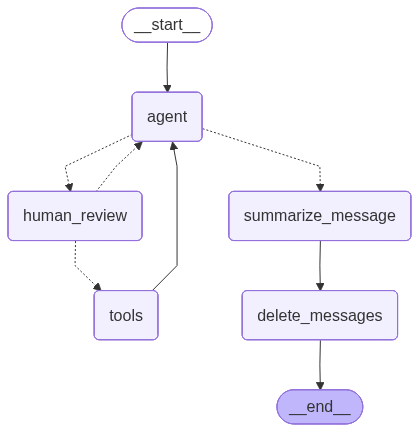

In [21]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))  


In [22]:
# 호출
from langchain_core.messages import HumanMessage

config = {
    'configurable' : {
        'thread_id' : 'paper_summary'
    }
}

query = 'LLM Survey 논문의 내용을 검색해서 요약해주세요' 
for chunk in graph.stream({'messages': [HumanMessage(query)], 'summary':''}, config=config, stream_mode='values'): # full state를 볼 수 있음
    chunk['messages'][-1].pretty_print()
    # pass


================================ Human Message =================================

LLM Survey 논문의 내용을 검색해서 요약해주세요
len(messages) == 1
================================== Ai Message ==================================
Tool Calls:
  arxiv (call_1y8WtkQwca1qFNvVKV1izMoV)
 Call ID: call_1y8WtkQwca1qFNvVKV1izMoV
  Args:
    query: LLM Survey
================================== Ai Message ==================================
Tool Calls:
  arxiv (call_1y8WtkQwca1qFNvVKV1izMoV)
 Call ID: call_1y8WtkQwca1qFNvVKV1izMoV
  Args:
    query: LLM Survey


In [23]:
# Tool Calls:
#   arxiv (call_ak2raIc3X3OXvjsX5otpO0zw)
#  Call ID: call_ak2raIc3X3OXvjsX5otpO0zw
#   Args:
#     query: Attention Is All You Need


# 해석 : arxiv 도구를 가지고 Args를 호출하겠다는 것. 

# ====================================================================================

# Tool Calls:
#   arxiv (call_OaNQebStvClLkDihWDPgYFp9)
#  Call ID: call_OaNQebStvClLkDihWDPgYFp9
#   Args:
#     query: LLM Survey
# ================================== Ai Message ==================================
# Tool Calls:
#   arxiv (call_OaNQebStvClLkDihWDPgYFp9)
#  Call ID: call_OaNQebStvClLkDihWDPgYFp9
#   Args:
#     query: LLM Survey


# 해석 : tool은 잘 불러왔는데, Args가 애매하다. 
# 논문의 제목이 정확하면 좋을 듯 하다. 

In [24]:
graph.get_state(config).values['messages']  # 현재 메시지 상태
#

[HumanMessage(content='LLM Survey 논문의 내용을 검색해서 요약해주세요', additional_kwargs={}, response_metadata={}, id='a956f14d-b2bf-430a-81d9-a48dbec0b862'),
 AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 16, 'prompt_tokens': 749, 'total_tokens': 765, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_c3320388fc', 'id': 'chatcmpl-DMP4WFt3SYMcYrhM2sdval1RoGZtX', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d1877-4af9-7722-ae06-c7945d21f76a-0', tool_calls=[{'name': 'arxiv', 'args': {'query': 'LLM Survey'}, 'id': 'call_1y8WtkQwca1qFNvVKV1izMoV', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 749, 'output_tokens': 

In [25]:
graph.get_state(config).next  # 다음 노드를 확인 : human_review에 멈춰있다. (interrupt)

('human_review',)

In [26]:
for chunk in graph.stream(
    # Command(resume={'action':'continue'}),  # 다시 시작. 
    Command(resume={'action':'update_args', 'data':{'query': 'Large language Mode: A Survey'}} ),   
    config=config,
    stream_mode = 'updates'
):
    print(chunk)

{'human_review': {'messages': [{'id': 'lc_run--019d1877-4af9-7722-ae06-c7945d21f76a-0', 'role': 'ai', 'content': '', 'tool_calls': [{'id': 'call_1y8WtkQwca1qFNvVKV1izMoV', 'name': 'arxiv', 'args': {'query': 'Large language Mode: A Survey'}}]}]}}
{'tools': {'messages': [ToolMessage(content="Published: 2015-08-17\nTitle: Observation of the rare $B^0_s\\toμ^+μ^-$ decay from the combined analysis of CMS and LHCb data\nAuthors: The CMS, LHCb Collaborations, :, V. Khachatryan, A. M. Sirunyan, A. Tumasyan, W. Adam, T. Bergauer, M. Dragicevic, J. Erö, M. Friedl, R. Frühwirth, V. M. Ghete, C. Hartl, N. Hörmann, J. Hrubec, M. Jeitler, W. Kiesenhofer, V. Knünz, M. Krammer, I. Krätschmer, D. Liko, I. Mikulec, D. Rabady, B. Rahbaran, H. Rohringer, R. Schöfbeck, J. Strauss, W. Treberer-Treberspurg, W. Waltenberger, C. -E. Wulz, V. Mossolov, N. Shumeiko, J. Suarez Gonzalez, S. Alderweireldt, S. Bansal, T. Cornelis, E. A. De Wolf, X. Janssen, A. Knutsson, J. Lauwers, S. Luyckx, S. Ochesanu, R. Rougny,

In [27]:
# {'human_review': None}
# {'tools': {'messages': [ToolMessage(content='Published: 2021-05-06\nTitle: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet\nAuthors: Luke Melas-Kyriazi\nSummary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifically, we replace the attention layer in a vision transformer with a feed-forward layer applied over the patch dimension. The resulting architecture is simply a series of feed-forward layers applied over the patch and feature dimensions in an alternating fashion. In experiments on ImageNet, this architecture performs surprisingly well: a ViT/DeiT-base-sized model obtains 74.9\\% top-1 accuracy, compared to 77.9\\% and 79.9\\% for ViT and DeiT respectively. These results indicate that aspects of vision transformers other than attention, such as the patch embedding, may be more responsible for their strong performance than previously thought. We hope these results prompt the community to spend more time trying to understand why our current models are as effective as they are.\n\nPublished: 2025-12-03\nTitle: "All You Need" is Not All You Need for a Paper Title: On the Origins of a Scientific Meme\nAuthors: Anton Alyakin\nSummary: The 2017 paper \'\'Attention Is All You Need\'\' introduced the Transformer architecture-and inadvertently spawned one of machine learning\'s most persistent naming conventions. We analyze 717 arXiv preprints containing \'\'All You Need\'\' in their titles (2009-2025), finding exponential growth ($R^2$ > 0.994) following the original paper, with 200 titles in 2025 alone. Among papers following the canonical \'\'X [Is] All You Need\'\' structure, \'\'Attention\'\' remains the most frequently claimed necessity (28 occurrences). Situating this phenomenon within memetic theory, we argue the pattern\'s success reflects competitive pressures in scientific communication that increasingly favor memorability over precision. Whether this trend represents harmless academic whimsy or symptomatic sensationalism, we leave-with appropriate self-awareness-to the reader.\n\nPublished: 2018-06-28\nTitle: Quit When You Can: Efficient Evaluation of Ensembles with Ordering Optimization\nAuthors: Serena Wang, Maya Gupta, Seungil You\nSummary: Given a classifier ensemble and a set of examples to be classified, many examples may be confidently and accurately classified after only a subset of the base models in the ensemble are evaluated. This can reduce both mean latency and CPU while maintaining the high accuracy of the original ensemble. To achieve such gains, we propose jointly optimizing a fixed evaluation order of the base models and early-stopping thresholds. Our proposed objective is a combinatorial optimization problem, but we provide a greedy algorithm that achieves a 4-approximation of the optimal solution for certain cases. For those cases, this is also the best achievable polynomial time approximation bound unless $P = NP$. Experiments on benchmark and real-world problems show that the proposed Quit When You Can (QWYC) algorithm can speed-up average evaluation time by $2$x--$4$x, and is around $1.5$x faster than prior work. QWYC\'s joint optimization of ordering and thresholds also performed better in experiments than various fixed orderings, including gradient boosted trees\' ordering.', name='arxiv', id='c2891224-8107-4d08-83dd-423a07afe9cb', tool_call_id='call_gfGPgP5Iggi7yX4TyaooCGWS')]}}
# len(messages) == 3
# {'agent': {'messages': [AIMessage(content='"Attention Is All You Need"는 Transformer 아키텍처를 소개한 혁신적인 논문으로, 자연어 처리 분야에서 큰 영향을 미쳤습니다. 이 논문은 사용자가 모델의 입력에 주의를 기울이는 방법에 대한 새로운 접근 방식을 제시하며, 시퀀스 데이터의 병렬 처리를 가능하게 하여 훈련 속도를 크게 향상시킵니다.\n\nTransformer 모델은 인코더와 디코더로 구성되어 있으며, 각 단위는 셀프 어텐션 메커니즘을 통해 입력 시퀀스 내의 모든 요소 간의 관계를 학습합니다. 이를 통해 기존의 순환 신경망(RNN)이나 장단기 메모리(Long Short-Term Memory, LSTM)와 같은 구조보다 더 효과적이고 효율적으로 장기 의존성을 처리할 수 있습니다.\n\n이 논문은 트랜스포머 모델을 사용하여 기계 번역 작업을 수행하는 실험을 포함하고 있으며, 기존의 최첨단 모델들에 비해 성능이 우수함을 보였습니다. 결국 이 연구는 자연어 처리의 여러 분야에서 Transformers의 사용을 촉진했고, 후속 연구들을 이끌어냈습니다.\n\n또한 최근 관련 논문에서 주목할 점은 어텐션 메커니즘 없이 단순한 피드 포워드 레이어로도 유사한 성능을 낼 수 있다는 연구도 있고, 이는 트랜스포머의 여러 요소 중 어텐션이 아닌 다른 요소들이 성능에 더 큰 기여를 할 수 있음을 시사합니다.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 342, 'prompt_tokens': 1489, 'total_tokens': 1831, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_c3320388fc', 'id': 'chatcmpl-DMOIiMF5ysLf9BALUKtn4QCs2vmyt', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d184a-1003-7a82-a53e-51f49521fdc8-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1489, 'output_tokens': 342, 'total_tokens': 1831, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]}}
# {'summarize_message': {'summary': '이제 "Attention Is All You Need" 논문에 대해 더 궁금한 점이 있으면 언제든지 물어보세요!'}}
# {'delete_messages': {'messages': [RemoveMessage(content='', additional_kwargs={}, response_metadata={}, id='0a128035-1226-4f51-ad1c-5d767d32792f')]}}

In [28]:
graph.get_state(config).values['messages']  # 실행이 잘 되었음

[HumanMessage(content='LLM Survey 논문의 내용을 검색해서 요약해주세요', additional_kwargs={}, response_metadata={}, id='a956f14d-b2bf-430a-81d9-a48dbec0b862'),
 AIMessage(content='', additional_kwargs={}, response_metadata={}, id='lc_run--019d1877-4af9-7722-ae06-c7945d21f76a-0', tool_calls=[{'name': 'arxiv', 'args': {'query': 'Large language Mode: A Survey'}, 'id': 'call_1y8WtkQwca1qFNvVKV1izMoV', 'type': 'tool_call'}], invalid_tool_calls=[]),
 ToolMessage(content="Published: 2015-08-17\nTitle: Observation of the rare $B^0_s\\toμ^+μ^-$ decay from the combined analysis of CMS and LHCb data\nAuthors: The CMS, LHCb Collaborations, :, V. Khachatryan, A. M. Sirunyan, A. Tumasyan, W. Adam, T. Bergauer, M. Dragicevic, J. Erö, M. Friedl, R. Frühwirth, V. M. Ghete, C. Hartl, N. Hörmann, J. Hrubec, M. Jeitler, W. Kiesenhofer, V. Knünz, M. Krammer, I. Krätschmer, D. Liko, I. Mikulec, D. Rabady, B. Rahbaran, H. Rohringer, R. Schöfbeck, J. Strauss, W. Treberer-Treberspurg, W. Waltenberger, C. -E. Wulz, V. Mossolov

In [29]:
for chunk in graph.stream(
    # Command(resume={'action':'continue'}),  # 다시 시작. 
    Command(resume={'action':'update_tool', 'data':'arxiv 말고 web에서 검색해주세요'} ),   
    config=config,
    stream_mode = 'updates'
):
    print(chunk)

{'human_review': {'messages': [{'tool_call_id': 'call_Y3WELrzPe0fjyrDMuykrwtNf', 'name': 'duckduckgo_search', 'role': 'tool', 'content': 'arxiv 말고 web에서 검색해주세요'}]}}
len(messages) == 5
{'agent': {'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 2562, 'total_tokens': 2583, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 2432}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_c3320388fc', 'id': 'chatcmpl-DMP6WoxKZcjdrmo5GYQkATM780cdR', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d1879-311f-7da0-b974-c9076bdce069-0', tool_calls=[{'name': 'duckduckgo_search', 'args': {'query': 'Large Language Model Survey summary'}, 'id': 'call_b6L6JaDbL9s2kvMqufYcvV

In [30]:
for chunk in graph.stream(
    Command(resume={'action':'continue'}),  # 다시 시작.  
    config=config,
    stream_mode = 'updates'
):
    print(f'chunk == {chunk}')

chunk == {'human_review': None}
chunk == {'tools': {'messages': [ToolMessage(content='5 days ago -The technical evolution of LLMs ... and use AI algorithms. In this survey,we review the recent advances of LLMs by introducing the background, key findings, and mainstream techniques.... March 23, 2025 -We alsogive an overview of techniques developed to build, and augment LLMs. We then survey popular datasets prepared for LLM training, fine-tuning, and evaluation, review widely used LLM evaluation metrics, and compare the performance of several ... September 9, 2025 -This surveyprovides an in-depth review of large language models (LLMs), highlighting the significant paradigm shift they represent in artificial intelligence. Our purpose is to consolidate state-of-the-art advances in LLM design, training, ... August 11, 2025 -This survey offers an in-depth review of Large Language Models (LLMs), highlighting the significant paradigm shift they represent in artificial intelligence. Our purpose

In [31]:
graph.get_state(config).values['messages'] 

[AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 2562, 'total_tokens': 2583, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 2432}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_c3320388fc', 'id': 'chatcmpl-DMP6WoxKZcjdrmo5GYQkATM780cdR', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d1879-311f-7da0-b974-c9076bdce069-0', tool_calls=[{'name': 'duckduckgo_search', 'args': {'query': 'Large Language Model Survey summary'}, 'id': 'call_b6L6JaDbL9s2kvMqufYcvV7e', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 2562, 'output_tokens': 21, 'total_tokens': 2583, 'input_token_details': {'audio': 0, 'cache_read': 2432}, 'output_token_deta

# 